In [1]:
from langgraph.graph import StateGraph , START , END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time
from rich import print

In [2]:
# 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str
    step3: str

In [3]:
# 2. define the steps
def step_1(state: CrashState) -> CrashState:
    print("Step 1 executed")
    return {"step1" : "done" , "input" : state["input"]}

def step_2(state : CrashState) -> CrashState:
    print("step 2 hangging ..... now mannually interrupt from the notebook toolbar (STOP BUTTON)")
    time.sleep(30) # Simulate long-running hang
    return {"step2" : "done"}

def step_3(state : CrashState) -> CrashState:
    print("Step 3 executed")
    return {"done" : True}

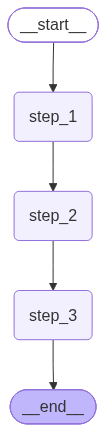

In [4]:
# 3. Build the Graph
builder = StateGraph(CrashState)

builder.add_node("step_1" , step_1)
builder.add_node("step_2" , step_2)
builder.add_node("step_3" , step_3)

builder.add_edge(START , "step_1")
builder.add_edge("step_1" , "step_2")
builder.add_edge("step_2" , "step_3")
builder.add_edge("step_3" , END)

checkpointer = InMemorySaver()

graph = builder.compile(checkpointer=checkpointer)
graph

In [8]:
# 4. Interupt get generated
try:
    print("Running graph: Please manually interrupt during step 2 .....")
    graph.invoke({"input" : "start"} , config = {"configurable" : {"thread_id" : "thread-1"}})
except KeyboardInterrupt:
    print("Kernel manually interrupted (crash simulated).")

Running graph: Please manually interrupt during step 2 .....

Step 1 executed

step 2 hangging ..... now mannually interrupt from the notebook toolbar (STOP BUTTON)

Kernel manually interrupted (crash simulated).

In [11]:
# 5. Get the history state of the graph
print(list(graph.get_state_history({"configurable" : {"thread_id" : "thread-1"}})))

[
    StateSnapshot(
        values={'input': 'start', 'step1': 'done', 'step2': 'done'},
        next=(),
        config={
            'configurable': {
                'thread_id': 'thread-1',
                'checkpoint_ns': '',
                'checkpoint_id': '1f188fd2-3d72-6bb7-8008-ca23367c571f'
            }
        },
        metadata={'source': 'loop', 'step': 8, 'parents': {}},
        created_at='2026-07-26T14:20:23.460344+00:00',
        parent_config={
            'configurable': {
                'thread_id': 'thread-1',
                'checkpoint_ns': '',
                'checkpoint_id': '1f188fd2-3d6b-6311-8007-b8d64f63183f'
            }
        },
        tasks=(),
        interrupts=()
    ),
    StateSnapshot(
        values={'input': 'start', 'step1': 'done', 'step2': 'done'},
        next=('step_3',),
        config={
            'configurable': {
                'thread_id': 'thread-1',
                'checkpoint_ns': '',
                'checkpoint_id': '1f188fd2-3d6b-6311-8007-b8d64f63183f'
            }
        },
        metadata={'source': 'loop', 'step': 7, 'parents': {}},
        created_at='2026-07-26T14:20:23.457256+00:00',
        parent_config={
            'configurable': {
                'thread_id': 'thread-1',
                'checkpoint_ns': '',
                'checkpoint_id': '1f188fd0-00a4-663d-8006-d09c21fb8d02'
            }
        },
        tasks=(
            PregelTask(
                id='5b11ad7c-590e-5d91-3e43-37e96c690e9b',
                name='step_3',
                path=('__pregel_pull', 'step_3'),
                error=None,
                interrupts=(),
                state=None,
                result={}
            ),
        ),
        interrupts=()
    ),
    StateSnapshot(
        values={'input': 'start', 'step1': 'done', 'step2': 'done'},
        next=('step_2',),
        config={
            'configurable': {
                'thread_id': 'thread-1',
                'checkpoint_ns': '',
                'checkpoint_id': '1f188fd0-00a4-663d-8006-d09c21fb8d02'
            }
        },
        metadata={'source': 'loop', 'step': 6, 'parents': {}},
        created_at='2026-07-26T14:19:23.397279+00:00',
        parent_config={
            'configurable': {
                'thread_id': 'thread-1',
                'checkpoint_ns': '',
                'checkpoint_id': '1f188fd0-009d-6113-8005-591bd2304523'
            }
        },
        tasks=(
            PregelTask(
                id='99365a62-4230-fb95-1cf1-34041b3ece43',
                name='step_2',
                path=('__pregel_pull', 'step_2'),
                error=None,
                interrupts=(),
                state=None,
                result={'step2': 'done'}
            ),
        ),
        interrupts=()
    ),
    StateSnapshot(
        values={'input': 'start', 'step1': 'done', 'step2': 'done'},
        next=('step_1',),
        config={
            'configurable': {
                'thread_id': 'thread-1',
                'checkpoint_ns': '',
                'checkpoint_id': '1f188fd0-009d-6113-8005-591bd2304523'
            }
        },
        metadata={'source': 'loop', 'step': 5, 'parents': {}},
        created_at='2026-07-26T14:19:23.394280+00:00',
        parent_config={
            'configurable': {
                'thread_id': 'thread-1',
                'checkpoint_ns': '',
                'checkpoint_id': '1f188fd0-009a-69ed-8004-0184a4e75a4d'
            }
        },
        tasks=(
            PregelTask(
                id='45aab584-b474-18e6-991c-8760a39b7fb2',
                name='step_1',
                path=('__pregel_pull', 'step_1'),
                error=None,
                interrupts=(),
                state=None,
                result={'step1': 'done', 'input': 'start'}
            ),
        ),
        interrupts=()
    ),
    StateSnapshot(
        values={'input': 'start', 'step1': 'done', 'step2': 'done'},
        next=('__start__',),
        config={
  

In [10]:
# 6. Re-run to shoe the fault tolerant resume
final_state = graph.invoke(None , config={"configurable" : {"thread_id" : "thread-1"}})
print("\n Final State: " , final_state)

step 2 hangging ..... now mannually interrupt from the notebook toolbar (STOP BUTTON)

Step 3 executed

Final State: 
{'input': 'start', 'step1': 'done', 'step2': 'done'}

In [13]:
# 7. Again Get the history state of the graph
print(graph.get_state({"configurable" : {"thread_id" : "thread-1"}}))

StateSnapshot(
    values={'input': 'start', 'step1': 'done', 'step2': 'done'},
    next=(),
    config={
        'configurable': {
            'thread_id': 'thread-1',
            'checkpoint_ns': '',
            'checkpoint_id': '1f188fd2-3d72-6bb7-8008-ca23367c571f'
        }
    },
    metadata={'source': 'loop', 'step': 8, 'parents': {}},
    created_at='2026-07-26T14:20:23.460344+00:00',
    parent_config={
        'configurable': {
            'thread_id': 'thread-1',
            'checkpoint_ns': '',
            'checkpoint_id': '1f188fd2-3d6b-6311-8007-b8d64f63183f'
        }
    },
    tasks=(),
    interrupts=()
)